In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


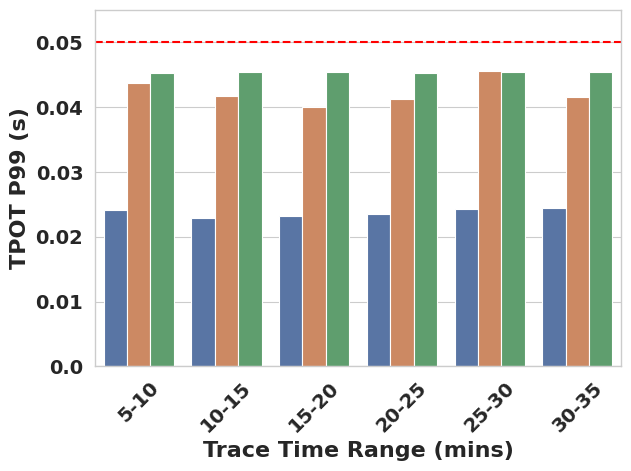

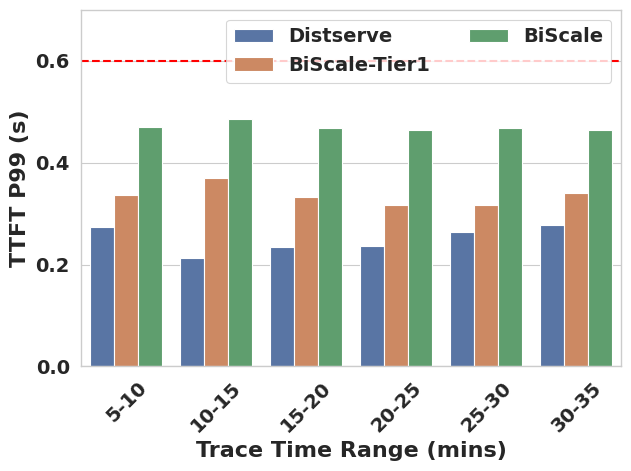

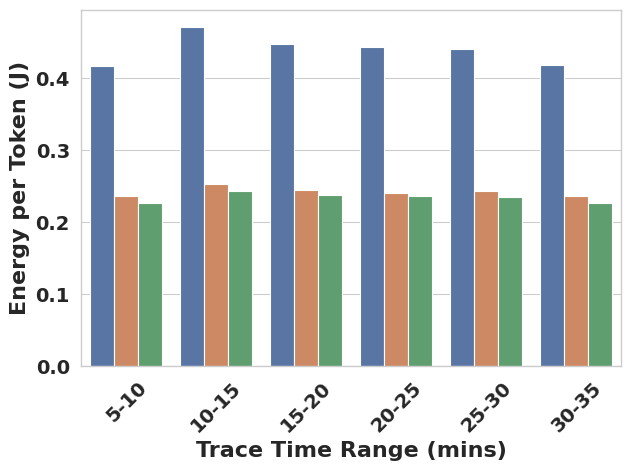

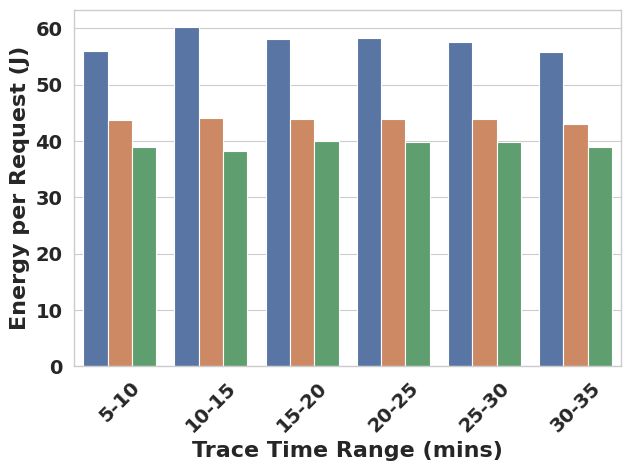

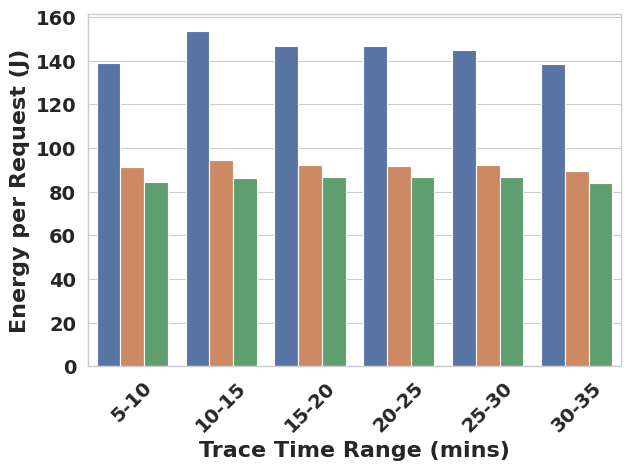

In [29]:
path_disag = "/export2/obasit/ClusterLevelServing/logs_asplos_tighter_tbt/profiler_logs_1_Aug17/disag/metrics.csv"
df_results_disag = pd.read_csv(path_disag)

path_coll = "/export2/obasit/ClusterLevelServing/logs_asplos_tighter_tbt/profiler_logs_1_Aug18/chunked/metrics.csv"
df_results_coll = pd.read_csv(path_coll)

df_results = pd.concat([df_results_disag, df_results_coll], ignore_index=True)

# Create a mapping for renaming expr_dir values
rename_mapping = {
    'DISTSERVE_AUG16_AZURE_SHAREGPT_P67_ORCALE_6': 'Distserve 85',
    'DISTSERVE_AUG16_AZURE_SHAREGPT_P67_ORCALE_5': 'Distserve 70',
    'DISTSERVE_AUG16_AZURE_SHAREGPT_P67_ORCALE_4': 'Distserve 55',
    'DISTSERVE_AUG16_AZURE_SHAREGPT_P67_ORCALE_3': 'Distserve 40',
    'DISTSERVE_AUG16_AZURE_SHAREGPT_P67_ORCALE_2': 'Distserve 25',
    'DISTSERVE_AUG16_AZURE_SHAREGPT_P67_ORCALE_1': 'Distserve 10',
    'OURS_AUG16_AZURE_SHAREGPT_P67_ORCALE_6': 'BiScale-Tier1 85',
    'OURS_AUG16_AZURE_SHAREGPT_P67_ORCALE_5': 'BiScale-Tier1 70',
    'OURS_AUG16_AZURE_SHAREGPT_P67_ORCALE_4': 'BiScale-Tier1 55',
    'OURS_AUG16_AZURE_SHAREGPT_P67_ORCALE_3': 'BiScale-Tier1 40',
    'OURS_AUG16_AZURE_SHAREGPT_P67_ORCALE_2': 'BiScale-Tier1 25',
    'OURS_AUG16_AZURE_SHAREGPT_P67_ORCALE_1': 'BiScale-Tier1 10',
    'OURS_AUG16_AZURE_SHAREGPT_P67_ORCALE_6_DVFS': 'BiScale 85',
    'OURS_AUG16_AZURE_SHAREGPT_P67_ORCALE_5_DVFS': 'BiScale 70',
    'OURS_AUG16_AZURE_SHAREGPT_P67_ORCALE_4_DVFS': 'BiScale 55',
    'OURS_AUG16_AZURE_SHAREGPT_P67_ORCALE_3_DVFS': 'BiScale 40',
    'OURS_AUG16_AZURE_SHAREGPT_P67_ORCALE_2_DVFS': 'BiScale 25',
    'OURS_AUG16_AZURE_SHAREGPT_P67_ORCALE_1_DVFS': 'BiScale 10',

}

# Replace values in expr_dir column
df_results['expr_dir'] = df_results['expr_dir'].replace(rename_mapping)

df_results = df_results[df_results["instance"] == "total"]

df_results = df_results[df_results["expr_dir"].isin(set(rename_mapping.values()))].copy()

# Sort the dataframe by extracting the numeric suffix from expr_dir
df_results['sort_key'] = df_results['expr_dir'].str.extract('(\d+)$')[0].fillna(0).astype(int)
df_results = df_results.sort_values('sort_key')

# Extract RPS and name from expr_dir
df_results['rps'] = df_results['expr_dir'].str.extract('(\d+)$')[0].astype(int)
df_results['name'] = df_results['expr_dir'].str.replace('\s+\d+$', '', regex=True)
# Set the order of the categories
# df_results['name'] = pd.Categorical(df_results['name'], categories=['Distserve', 'BiScale-Tier1', 'BiScale', 'Collocated-Tier1', 'Collocated'], ordered=True)
df_results['name'] = pd.Categorical(df_results['name'], categories=['Distserve', 'BiScale-Tier1', 'BiScale'], ordered=True)
df_results = df_results.sort_values(['rps', 'name'])

#################### TPOT P99 ####################

sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps", 
    y="tpot_p99", 
    hue="name", 
    data=df_results, 
    dodge=True
)
ax.axhline(y=0.05, color='red', linestyle='--', linewidth=1.5)

# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=16, fontweight='bold')
ax.set_ylabel('TPOT P99 (s)', fontsize=16, fontweight='bold')
ax.set_ylim(0, 0.055)
ax.set_xticks([0, 1, 2, 3, 4, 5])
# ax.set_xlim(0.5, 6.5)
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center', fontweight='bold')
ax.set_yticks([0.0, 0.01, 0.02, 0.03, 0.04, 0.05])
ax.set_yticklabels(['0.0', '0.01', '0.02', '0.03', '0.04', '0.05'], fontsize=14, fontweight='bold')
ax.legend_.remove()
plt.tight_layout()
plt.savefig("figs/p67_oracle_tpot.pdf", format="pdf")

#################### TTFT P99 ####################

sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps", 
    y="ttft_p99", 
    hue="name", 
    data=df_results, 
    dodge=True
)
ax.axhline(y=0.6, color='red', linestyle='--', linewidth=1.5)

# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=16, fontweight='bold')
ax.set_ylabel('TTFT P99 (s)', fontsize=16, fontweight='bold')
ax.set_ylim(0, 0.7)
ax.set_xticks([0, 1, 2, 3, 4, 5])
# ax.set_xlim(0.5, 6.5)
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center', fontweight='bold')
ax.set_yticks([0.0, 0.2, 0.4, 0.6])
ax.set_yticklabels(['0.0', '0.2', '0.4', '0.6'], fontsize=14, fontweight='bold')
ax.legend(title="", ncol=2, prop={"size": 14, "weight": "bold"})
plt.tight_layout()
plt.savefig("figs/p67_oracle_ttft.pdf", format="pdf")

#################### Energy per token - decode ####################
sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps", 
    y="decode_energy_per_token", 
    hue="name", 
    data=df_results, 
    dodge=True,
)

# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=16, fontweight='bold')
ax.set_ylabel('Energy per Token (J)', fontsize=16, fontweight='bold')
ax.set_xticks([0, 1, 2, 3, 4, 5])
# ax.set_xlim(0.5, 6.5)
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center', fontweight='bold')
ax.tick_params(axis='y', labelsize=14)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
ax.legend_.remove()
plt.tight_layout()
plt.savefig("figs/p67_oracle_energy_per_token_decode.pdf", format="pdf")

#################### Energy per token - prefill ####################
sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps", 
    y="prefill_energy_per_token", 
    hue="name", 
    data=df_results, 
    dodge=True,
)

# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=16, fontweight='bold')
ax.set_ylabel('Energy per Request (J)', fontsize=16, fontweight='bold')
ax.set_xticks([0, 1, 2, 3, 4, 5])
# ax.set_xlim(0.5, 6.5)
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center', fontweight='bold')
ax.tick_params(axis='y', labelsize=14)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
ax.legend_.remove()
plt.tight_layout()
plt.savefig("figs/p67_oracle_energy_per_request_prefill.pdf", format="pdf")

#################### Energy per token - total ####################
df_results['energy_per_req'] = df_results['energy_j'] / df_results['num_requests']
sns.set_theme(context="paper", style="whitegrid")
plt.figure()
ax = sns.barplot(
    x="rps", 
    y="energy_per_req", 
    hue="name", 
    data=df_results, 
    dodge=True,
)

# Customize the plot
ax.set_xlabel('Trace Time Range (mins)', fontsize=16, fontweight='bold')
ax.set_ylabel('Energy per Request (J)', fontsize=16, fontweight='bold')
ax.set_xticks([0, 1, 2, 3, 4, 5])
# ax.set_xlim(0.5, 6.5)
ax.set_xticklabels(['5-10', '10-15', '15-20', '20-25', '25-30', '30-35'], fontsize=14, rotation=45, ha='center', fontweight='bold')
ax.tick_params(axis='y', labelsize=14)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
ax.legend_.remove()
plt.tight_layout()
plt.savefig("figs/p67_oracle_energy_per_request_total.pdf", format="pdf")

In [30]:
df_results = df_results[df_results["name"].isin(["Distserve", "BiScale-Tier1", "BiScale"])].copy()

# Normalize energy with Distserve energy for both prefill and decode
df_results['energy_norm_prefi_D'] = df_results.apply(
    lambda row: (1 - row['prefill_energy_per_token'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'Distserve')
    ]['prefill_energy_per_token'].values[0]) * 100,
    axis=1
)
df_results['energy_norm_deco_D'] = df_results.apply(
    lambda row: (1 - row['decode_energy_per_token'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'Distserve')
    ]['decode_energy_per_token'].values[0]) * 100,
    axis=1
)
df_results['energy_norm_prefi_M'] = df_results.apply(
    lambda row: (1 - row['prefill_energy_per_token'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'BiScale-Tier1')
    ]['prefill_energy_per_token'].values[0]) * 100,
    axis=1
)
df_results['energy_norm_deco_M'] = df_results.apply(
    lambda row: (1 - row['decode_energy_per_token'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'BiScale-Tier1')
    ]['decode_energy_per_token'].values[0]) * 100,
    axis=1
)
df_results['energy_norm_D'] = df_results.apply(
    lambda row: (1 - row['energy_per_req'] / df_results[
        (df_results['rps'] == row['rps']) & (df_results['name'] == 'Distserve')
    ]['energy_per_req'].values[0]) * 100,
    axis=1
)
df_results['energy_share_prefill'] = df_results['energy_prefill'] / (df_results['energy_j']) * 100
df_results['energy_share_decode'] = df_results['energy_decode'] / (df_results['energy_j']) * 100
df_results[['expr_dir', 'energy_j', 'energy_prefill', 'energy_decode', 'energy_per_token', 'energy_per_req', 'energy_share_prefill', 'energy_share_decode', 'energy_norm_prefi_D', 'energy_norm_deco_D', 'energy_norm_prefi_M', 'energy_norm_deco_M', 'energy_norm_D']].sort_values('expr_dir', ascending=False)

,expr_dir,energy_j,energy_prefill,energy_decode,energy_per_token,energy_per_req,energy_share_prefill,energy_share_decode,energy_norm_prefi_D,energy_norm_deco_D,energy_norm_prefi_M,energy_norm_deco_M,energy_norm_D
99,Distserve 85,2.087866e+06,840651.171508,1.247214e+06,0.695426,138.765490,40.263664,59.736336,0.000000,0.000000,-29.674319,-76.711893,0.000000
93,Distserve 70,2.043195e+06,811105.513163,1.232089e+06,0.727249,145.113277,39.697901,60.302099,0.000000,0.000000,-31.042073,-81.633110,0.000000
87,Distserve 55,2.038269e+06,809309.157900,1.228960e+06,0.731705,146.648626,39.705704,60.294296,0.000000,0.000000,-32.580611,-84.107033,0.000000
81,Distserve 40,2.032838e+06,805216.863357,1.227622e+06,0.737014,146.680021,39.610471,60.389529,0.000000,0.000000,-32.489887,-83.033834,0.000000
75,Distserve 25,1.973167e+06,774149.017497,1.199018e+06,0.770990,153.673409,39.233840,60.766160,0.000000,0.000000,-36.483550,-86.211564,0.000000
69,Distserve 10,2.097194e+06,844574.534025,1.252620e+06,0.693526,138.887037,40.271641,59.728359,0.000000,0.000000,-27.742648,-76.021253,0.000000
347,BiScale-Tier1 85,1.349862e+06,648192.668890,7.016692e+05,0.452239,89.727591,48.019185,51.980815,22.883728,43.410713,0.000000,0.000000,35.338685
335,BiScale-Tier1 70,1.297193e+06,619009.682417,6.781829e+05,0.461825,92.123612,47.719181,52.280819,23.688631,44.943959,0.000000,0.000000,36.516069
323,BiScale-Tier1 55,1.278430e+06,610647.581961,6.677825e+05,0.458758,91.946926,47.765427,52.234573,24.574190,45.683770,0.000000,0.000000,37.301202
311,BiScale-Tier1 40,1.279215e+06,607625.667042,6.715892e+05,0.463179,92.322091,47.499890,52.500110,24.522541,45.365292,0.000000,0.000000,37.058851
